<a href="https://colab.research.google.com/github/mayssajr/eHealthChain/blob/main/Code_reconaissance_PFE_2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#lier colab avec drive
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#importation des bibliothéques necessaires
import numpy as np  #faire des fonctions mathematiques
import tensorflow as tf  #pour l'apprentissage automatique et en particulier pour la construction et le déploiement de réseaux de neurones
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt #pour la création et la visualisation de graphiques et de tracés
import cv2 #traitement et manipulation d'images
from google.colab.patches import cv2_imshow # le mise à jour de cv2.imshow
from keras.models import load_model #charger le model

**Data Preprocessing**

Training Image preprocessing

In [ ]:
training_set = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/PFE/Projet/images/train', #imortation des images de train
    labels="inferred", #chaque sous-répertoire sera considéré comme une classe et les images dans ces sous-répertoires seront étiquetées en conséquence.
    label_mode="categorical", #les étiquettes seront représentées sous forme de vecteurs binaires pour chaque classe.
    class_names=None, #spécifier manuellement les noms de classe
    color_mode="rgb",#es images seront chargées en utilisant le mode de couleur RGB
    batch_size=32,# les données d'entraînement seront divisées en lots de 32 images lors de l'entrainement.
    image_size=(64, 64),#Les images seront redimensionnées à une taille de 64x64 pixels
    shuffle=True,#Les données seront mélangées aléatoirement à chaque époque d'entraînement
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 1530 files belonging to 2 classes.


Test Image preprocessing

In [ ]:

test_set = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/PFE/Projet/images/test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(64, 64),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 196 files belonging to 2 classes.


In [ ]:
cnn = tf.keras.models.Sequential()

In [ ]:
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu',input_shape=[64,64,3]))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [ ]:
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [ ]:
cnn.add(tf.keras.layers.Dropout(0.5))

In [ ]:
cnn.add(tf.keras.layers.Flatten())

In [ ]:
cnn.add(tf.keras.layers.Dense(units=128,activation='relu'))

In [ ]:
cnn.add(tf.keras.layers.Dense(units=2,activation='softmax'))

In [ ]:
cnn.compile(optimizer='rmsprop',loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
training_history = cnn.fit(x=training_set,validation_data=test_set,epochs=20)

Epoch 1/20
48/48 [==============================] - 343s 6s/step - loss: 11.1268 - accuracy: 0.8660 - val_loss: 1.5527 - val_accuracy: 0.8520
Epoch 2/20
48/48 [==============================] - 13s 231ms/step - loss: 0.9192 - accuracy: 0.8745 - val_loss: 0.9611 - val_accuracy: 0.8673
Epoch 3/20
48/48 [==============================] - 13s 232ms/step - loss: 0.5731 - accuracy: 0.9314 - val_loss: 0.4005 - val_accuracy: 0.9031
Epoch 4/20
48/48 [==============================] - 13s 222ms/step - loss: 0.1328 - accuracy: 0.9673 - val_loss: 1.8573 - val_accuracy: 0.8673
Epoch 5/20
48/48 [==============================] - 14s 256ms/step - loss: 0.2321 - accuracy: 0.9627 - val_loss: 0.3565 - val_accuracy: 0.9694
Epoch 6/20
48/48 [==============================] - 14s 252ms/step - loss: 0.1314 - accuracy: 0.9791 - val_loss: 0.2602 - val_accuracy: 0.9643
Epoch 7/20
48/48 [==============================] - 12s 222ms/step - loss: 0.1952 - accuracy: 0.9771 - val_loss: 1.0623 - val_accuracy: 0.7551


In [ ]:
cnn.save("trained_model.h5")

In [ ]:
#Recording History
import json
with open('training_hist.json', 'w') as f:
    json.dump(training_history.history, f)

In [ ]:
training_history.history

{'loss': [11.126770973205566,
  0.9191630482673645,
  0.5730971097946167,
  0.13279342651367188,
  0.23206621408462524,
  0.13142074644565582,
  0.19519032537937164,
  0.1050090491771698,
  0.18873943388462067,
  0.11974134296178818,
  0.07525995373725891,
  0.150327667593956,
  0.106477752327919,
  0.04612564295530319,
  0.08957086503505707,
  0.059346333146095276,
  0.10656782239675522,
  0.16171284019947052,
  0.07289495319128036,
  0.013624081388115883],
 'accuracy': [0.8660130500793457,
  0.8745098114013672,
  0.9313725233078003,
  0.9673202633857727,
  0.9627450704574585,
  0.9790849685668945,
  0.9771241545677185,
  0.9738562107086182,
  0.9745097756385803,
  0.9830065369606018,
  0.983660101890564,
  0.9823529124259949,
  0.98562091588974,
  0.9908496737480164,
  0.9915032386779785,
  0.9915032386779785,
  0.9875816702842712,
  0.9895424842834473,
  0.9921568632125854,
  0.998039186000824],
 'val_loss': [1.5527337789535522,
  0.9610834121704102,
  0.40045562386512756,
  1.85732

In [ ]:
print(training_history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


In [ ]:
print('Test set Accuracy: {} %'.format(training_history.history['val_accuracy'][-1]*100))

Test set Accuracy: 91.8367326259613 %


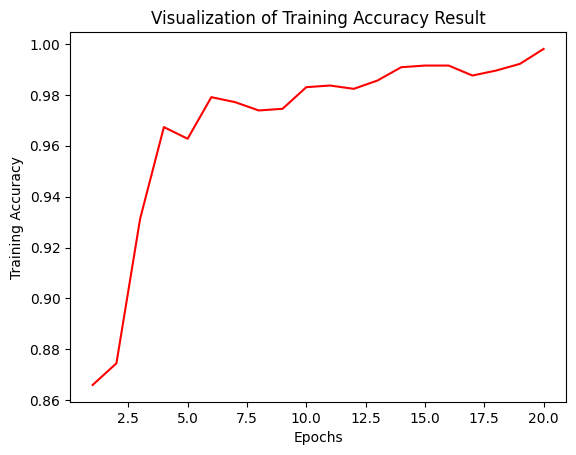

In [ ]:
epochs=[i for i in range(1,21)]
plt.plot(epochs,training_history.history['accuracy'],color='red')
plt.xlabel('Epochs')
plt.ylabel('Training Accuracy')
plt.title("Visualization of Training Accuracy Result")
plt.show()

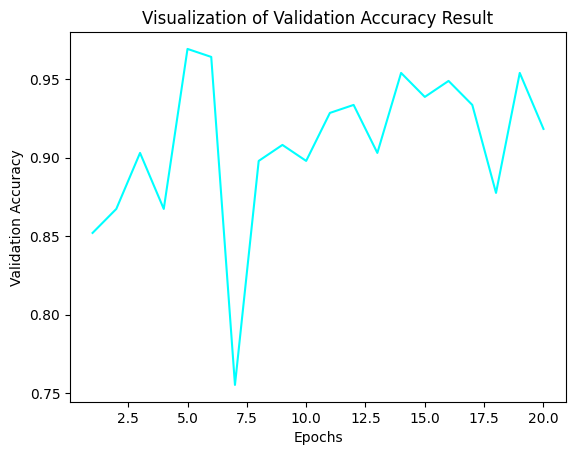

In [ ]:
plt.plot(epochs,training_history.history['val_accuracy'],color='cyan')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title("Visualization of Validation Accuracy Result")
plt.show()

In [ ]:
acc = training_history.history['accuracy']
val_acc = training_history.history['val_accuracy']

loss = training_history.history['loss']
val_loss = training_history.history['val_loss']

In [ ]:
EPOCHS=20

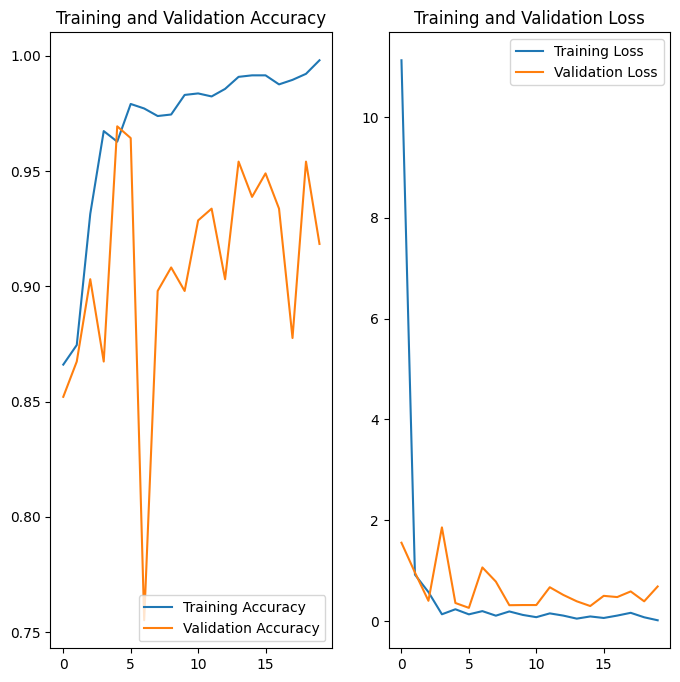

In [ ]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
test_set = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/PFE/Projet/images/test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(64, 64),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 196 files belonging to 2 classes.


In [ ]:
cnn = tf.keras.models.load_model('/content/trained_model.h5')

In [ ]:


# Charger le modèle de reconnaissance faciale
model = load_model('/content/trained_model.h5')

# Définir les paramètres de la détection de visage
face_cascade = cv2.CascadeClassifier('/content/drive/MyDrive/haarcascade.xml')

# Ouvrir la vidéo
cap = cv2.VideoCapture('/content/vido.mp4')
frame_number = 1


# Boucle sur les images de la vidéo
while cap.isOpened():
    # Lire l'image suivante
    ret, frame = cap.read()
    if not ret:
        break

    # Convertir l'image en niveaux de gris pour la détection de visage
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Détecter les visages dans l'image
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    # Boucle sur les visages détectés
    for (x, y, w, h) in faces:
        # Extraire la région d'intérêt (ROI) correspondant au visage
        roi = frame[y:y+h, x:x+w]

        # Redimensionner la ROI pour l'adapter au modèle de reconnaissance faciale
        roi = cv2.resize(roi, (64, 64))


        # Prétraiter l'image pour le modèle de reconnaissance faciale
        roi = roi.astype('float') / 255.0
        roi = np.expand_dims(roi, axis=0)

        # Faire la prédiction du modèle de reconnaissance faciale
        prediction = model.predict(roi)

        # Dessiner un rectangle autour du visage détecté
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)


    # Afficher l'image avec les rectangles de détection de visage
    cv2_imshow(frame)
    if cv2.waitKey(1) == ord('q'):
        break


# Libérer les ressources
cap.release()
cv2.destroyAllWindows()


error: ignored

In [ ]:
import cv2

# Ouvrir le fichier vidéo pour la lecture
cap = cv2.VideoCapture('/content/vido.mp4')

# Lire la première image
ret, frame = cap.read()

# Enregistrer l'image sous forme de fichier JPG
cv2.imwrite('image.jpg', frame)
cv2_imshow(frame)
# Fermer la capture vidéo
cap.release()


error: ignored

In [ ]:
import cv2
image_path= '/content/image.jpg'
img=cv2.imread(image_path)
plt.imshow(img)
plt.title('Test image')
plt.xticks([])
plt.yticks([])
plt.show()



In [ ]:
import cv2

# Displaying the image
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

In [ ]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(64,64))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions = cnn.predict(input_arr)

In [ ]:
#test_set.class_names
print(predictions)

In [ ]:
result_index = np.where(predictions[0] == max(predictions[0]))
print(result_index)

In [ ]:
# Displaying the image
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

In [ ]:
print("It's  {}".format(test_set.class_names[result_index[0][0]]))

In [ ]:
# Prédire les classes des images de test
y_pred = cnn.predict(test_set)
y_pred = np.argmax(y_pred, axis=1)  # Convertir les probabilités en classes prédites

# Obtenir les vraies classes des images de test
y_true = np.concatenate([y for x, y in test_set], axis=0)
y_true = np.argmax(y_true, axis=1)  # Convertir les vecteurs de classes en classes

# Calculer la matrice de confusion
from sklearn.metrics import confusion_matrix
confusion_mat = confusion_matrix(y_true, y_pred)

print(confusion_mat)